# AppleBee — evaluation and long-term simulation

Three steps, building from one sub-model to a whole region:

1. **Evaluate the egg-production sub-model** against *Osmia cornifrons* nesting
   data from 17 New York apple orchards (Centrella et al. 2020). Emergence is
   *observed* here, so this isolates one sub-model.
2. **Evaluate the whole AppleBee model** against six years of *Osmia* monitoring
   at a single Pennsylvania site (Turley et al. 2022). All four sub-models now
   run in sequence, and emergence is *predicted*.
3. **Simulate 16 years across the region** — 7,452 grid cells, to show how
   reproductive success varies in space and time.

Data is catalogued in [`data/inputs/MANIFEST.md`](../data/inputs/MANIFEST.md);
the model lives in `applebee/`.

> **Region note.** Step 3 runs over the **Northeast** — 44,756 cells across
> 13 states — using inputs fetched from source by `applebee.acquire`: PRISM daily
> weather verified 100.0000% identical to the archived Pennsylvania export, and a
> Lonsdorf forage index built from the USDA national Cropland Data Layer. If those
> inputs are absent the section falls back to Pennsylvania alone, so the notebook
> runs either way.

**Prerequisite:** `data/cache/` must hold the parsed PRISM matrices. If not, run
`python scripts/build_cache.py` once (~2 min).

---
## 0. Setup

In [1]:
import sys, warnings, time
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "applebee").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from scipy import stats

warnings.filterwarnings("ignore")
pd.set_option("display.width", 170, "display.max_columns", 50)
plt.rcParams.update({"figure.dpi": 110, "figure.figsize": (8, 4.5), "axes.grid": True,
                     "grid.alpha": 0.3, "axes.spines.top": False, "axes.spines.right": False})

from applebee import AppleBee, ForageGrid, ModelParams, load_weather
from applebee.config import (CENTRELLA_CSV, PA_FORAGE_CSV, PA_PPT_CSV, PA_TMEAN_CSV,
                             TURLEY_CSV, MONITORING_SITE_LAT, MONITORING_SITE_LON, TABLES)
from applebee.evaluation import centrella as C
from applebee.evaluation import turley as T

print("root:", ROOT)
print("model parameters — every default traceable to Tables 4-1 to 4-4:")
pd.DataFrame([{"parameter": f, "default": getattr(ModelParams(), f),
               "calibrated": getattr(ModelParams.calibrated(), f)}
              for f in ModelParams().__dataclass_fields__])

root: /Users/edwardamoah/Documents/GitHub/AppleBee
model parameters — every default traceable to Tables 4-1 to 4-4:


,parameter,default,calibrated
0,emergence_base_temp,6.53,6.53
1,emergence_thermal_constant,209.0,209.0
2,emergence_start_doy,1,1
3,mating_days,2,2
4,longevity,22,22
5,temperature_threshold,13.9,18.72
6,precipitation_threshold,5.0,4.33
7,forage_threshold,0.5,0.54
8,eggs_high_forage,2,2
9,eggs_low_forage,1,1


---
# Part 1 — The egg-production sub-model

> Centrella, M., Russo, L., Moreno Ramírez, N., Eitzer, B., van Dyke, M.,
> Danforth, B. & Poveda, K. (2020). Diet diversity and pesticide risk mediate the
> negative effects of land use change on solitary bee offspring production.
> *Journal of Applied Ecology*, 57(6), 1031–1042.

17 Finger Lakes apple orchards, each stocked with ~100 *O. cornifrons* on
5 May 2015. Bees emerged 7 May; completed nest tubes were collected roughly every
six days to 24 June. **51 observations = 17 sites × 3 collection windows.**

Because emergence is observed rather than predicted, this tests Equations
4.2–4.3 alone: on each day, a female lays eggs if it is warm enough
(`T ≥ T_H`) and dry enough (`P ≤ P_H`), at 2 eggs/day where the forage index
clears `L_H` and 1 otherwise.

In [2]:
data = C.load_centrella()          # response: cells = (males + females) / (1 - larval mortality)
obs = data.observations

print(f"{len(obs)} observations across {obs.Site.nunique()} sites\n")
display(obs[["Site", "Time_Point", "collection_date", "males", "females",
             "larval_mortality", "observed_eggs"]].head(8))

print("site weather and forage (New York, 2015):")
print(f"  tmean grid : {data.tmean.n_cells} cells x {len(data.tmean.dates)} days "
      f"({data.tmean.dates[0].date()} .. {data.tmean.dates[-1].date()})")
print(f"  forage index across sites: {data.sites.forage_quality.min():.3f} - "
      f"{data.sites.forage_quality.max():.3f} (mean {data.sites.forage_quality.mean():.3f})")

51 observations across 17 sites



,Site,Time_Point,collection_date,males,females,larval_mortality,observed_eggs
0,AB,1,2015-05-20,5,10,0.105263,16.764706
1,AB,2,2015-05-28,67,36,0.065421,110.210000
2,AB,3,2015-06-03,19,7,0.000000,26.000000
3,BA,1,2015-05-25,26,19,0.238095,59.062500
4,BA,2,2015-05-29,66,40,0.193333,131.404959
5,BA,3,2015-06-04,16,17,0.183673,40.425000
6,BD,1,2015-05-23,28,50,0.066667,83.571429
7,BD,2,2015-05-30,14,11,0.000000,25.000000


site weather and forage (New York, 2015):
  tmean grid : 17 cells x 61 days (2015-05-01 .. 2015-06-30)
  forage index across sites: 0.344 - 0.588 (mean 0.454)


### Response variable

The chapter regresses observed **brood cells**. The published dataset records
emerged adults and a larval-mortality proportion, so cells are reconstructed as

$$\text{cells} = \frac{\text{males} + \text{females}}{1 - \text{larval mortality}}$$

Note the ceiling this puts on the reconstruction: because mortality is bounded
below by 0, the result can never be smaller than the adult count.

In [3]:
summary = pd.DataFrame({
    "emerged adults (M+F)": obs.emerged_adults.describe()[["max","mean","min","std"]],
    "reconstructed cells":  obs.observed_eggs.describe()[["max","mean","min","std"]],
}).T.round(1)
summary.columns = ["max", "mean", "min", "SD"]
summary.loc["chapter reports"] = [206, 65, 12, 42]
display(summary)
print(f"rows with larval mortality exactly 0 (no correction applied): "
      f"{(obs.larval_mortality == 0).sum()} of {len(obs)}")

,max,mean,min,SD
emerged adults (M+F),175.0,45.7,4.0,37.6
reconstructed cells,182.4,51.6,4.0,41.2
chapter reports,206.0,65.0,12.0,42.0


rows with larval mortality exactly 0 (no correction applied): 11 of 51


### Predictions and the hybrid mixed-effects fit (Eq. 4.9)

The sub-model predicts eggs **per female**; observations are site totals across ~100 bees. The evaluation is therefore a *hybrid* model — observed totals regressed on the prediction, with time point fixed and site as a random intercept.

In [4]:
design = C.build_design(data, ModelParams())
display(design[["Site","Time_Point","window_start","window_days","forage_quality",
                "foraging_days","predicted_eggs","observed_eggs"]].head(8))
print("predicted eggs per female per 6-day window: "
      f"max={design.predicted_eggs.max():.0f} mean={design.predicted_eggs.mean():.1f} "
      f"min={design.predicted_eggs.min():.0f}")

,Site,Time_Point,window_start,window_days,forage_quality,foraging_days,predicted_eggs,observed_eggs
0,AB,1,2015-05-14,6,0.465625,3,3,16.764706
1,AB,2,2015-05-22,6,0.465625,3,3,110.210000
2,AB,3,2015-05-28,6,0.465625,3,3,26.000000
3,BA,1,2015-05-19,6,0.343750,1,1,59.062500
4,BA,2,2015-05-23,6,0.343750,4,4,131.404959
5,BA,3,2015-05-29,6,0.343750,2,2,40.425000
6,BD,1,2015-05-17,6,0.378125,3,3,83.571429
7,BD,2,2015-05-24,6,0.378125,5,5,25.000000


predicted eggs per female per 6-day window: max=10 mean=3.5 min=1


In [5]:
# Marginal R2 uses the fixed effects alone; conditional adds the random intercepts.
def r2_split(design, fit, response, predictor, factor=None):
    y = design[response].to_numpy(float)
    ss_tot = ((y - y.mean()) ** 2).sum()
    fixed = fit.params["Intercept"] + fit.params[predictor] * design[predictor]
    if factor:
        for key in fit.params.index:
            if key.startswith(f"C({factor})"):
                level = int(key.split("T.")[1].rstrip("]"))
                fixed = fixed + fit.params[key] * (design[factor] == level)
    return (1 - ((y - fixed) ** 2).sum() / ss_tot,                 # marginal
            1 - ((y - fit.fittedvalues) ** 2).sum() / ss_tot)      # conditional

results1 = {}
for label, params in [("default", ModelParams()), ("calibrated", ModelParams.calibrated())]:
    d = C.build_design(data, params)
    fit = C.fit_lme(d)
    marg, cond = r2_split(d, fit, "observed_eggs", "predicted_eggs", "Time_Point")
    results1[label] = {"marginal R2": marg, "conditional R2": cond,
                       "RMSE": C.r2_and_rmse(d.observed_eggs, fit.fittedvalues)[1],
                       "slope": float(fit.params["predicted_eggs"]),
                       "slope p": float(fit.pvalues["predicted_eggs"])}
tbl = pd.DataFrame(results1).T.round(4)
tbl["chapter R2"] = [0.52, 0.60]
display(tbl)

gain = results1["calibrated"]["conditional R2"] - results1["default"]["conditional R2"]
print(f"gain from calibration: {gain:+.3f}   (chapter reports +0.08)")
print("the slope only becomes significant after calibration: "
      f"p {results1['default']['slope p']:.3f} -> {results1['calibrated']['slope p']:.3f}")

,marginal R2,conditional R2,RMSE,slope,slope p,chapter R2
default,0.1752,0.4096,31.3517,5.2947,0.1220,0.52
calibrated,0.2717,0.4771,29.5036,13.0515,0.0024,0.60


gain from calibration: +0.068   (chapter reports +0.08)
the slope only becomes significant after calibration: p 0.122 -> 0.002


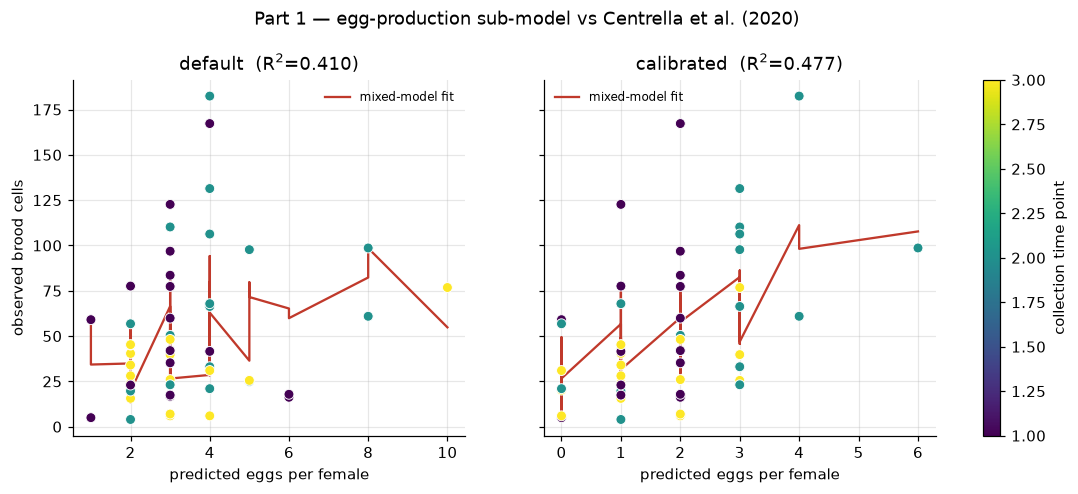

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
for ax, (label, params) in zip(axes, [("default", ModelParams()),
                                      ("calibrated", ModelParams.calibrated())]):
    d = C.build_design(data, params)
    fit = C.fit_lme(d)
    sc = ax.scatter(d.predicted_eggs, d.observed_eggs, c=d.Time_Point, cmap="viridis",
                    s=42, edgecolor="white", linewidth=0.6, zorder=3)
    order = np.argsort(d.predicted_eggs.to_numpy())
    ax.plot(d.predicted_eggs.to_numpy()[order], np.asarray(fit.fittedvalues)[order],
            color="#c0392b", lw=1.5, label="mixed-model fit")
    ax.set(xlabel="predicted eggs per female",
           title=f"{label}  (R$^2$={results1[label]['conditional R2']:.3f})")
    ax.legend(frameon=False, fontsize=8)
axes[0].set_ylabel("observed brood cells")
fig.colorbar(sc, ax=axes, label="collection time point", fraction=0.03)
fig.suptitle("Part 1 — egg-production sub-model vs Centrella et al. (2020)", y=1.03)
plt.show()

**Read.** The relationship is real but modest, and the *calibration effect*
reproduces the chapter closely (+0.07 against +0.08). The absolute level sits
about 0.11 below the chapter's, which traces to the response variable: the
published dataset records emerged adults, not the raw brood-cell tallies the
chapter counted, and roughly 20% of cells produce neither an emerged adult nor a
recorded larval death. See §3 of `docs/REPLICATION_NOTES.md`.

---
# Part 2 — The whole AppleBee model at one Pennsylvania site

> Turley, N. et al. (2022). Dryad `doi:10.5061/dryad.9kd51c5mc`.

Blue vane traps at eight locations around the Penn State Fruit Research and
Extension Center, Adams County PA, weekly April–October 2014–2019. All eight
fall inside one 4 km PRISM cell.

Now all four sub-models run in sequence and **emergence is predicted, not
observed**:

$$R = E \times (1 - M) \times (1 - W)$$

Offspring produced in weather year *Y* are the adults counted in spring *Y+1*.

In [7]:
tmean  = load_weather(PA_TMEAN_CSV, "pa_tmean")
ppt    = load_weather(PA_PPT_CSV,   "pa_ppt")
forage = ForageGrid.load(PA_FORAGE_CSV)
model  = AppleBee(tmean, ppt, forage, ModelParams())

print(f"PA weather : {tmean.n_cells:,} cells x {len(tmean.dates):,} days "
      f"({tmean.dates[0].date()} .. {tmean.dates[-1].date()})")
ftab = forage.table.reset_index()
print(f"PA forage  : {len(ftab):,} cell-years, {ftab.year.min()}-{ftab.year.max()}")

col, row = T.nearest_cell(tmean.cells, MONITORING_SITE_LAT, MONITORING_SITE_LON)
print(f"\nmonitoring site {MONITORING_SITE_LAT}, {MONITORING_SITE_LON} -> grid cell ({col}, {row})")

PA weather : 7,452 cells x 12,601 days (1990-01-01 .. 2024-07-01)
PA forage  : 117,780 cell-years, 2008-2023

monitoring site 39.935226, -77.25453 -> grid cell (1146, 240)


### One year, step by step

The clearest way to check the lifecycle wiring is to watch a single cell-year through all four sub-models.

In [8]:
demo = model.run_grid_year(col, row, 2018)
for k, v in vars(demo).items():
    print(f"  {k:26s} {v}")
print(f"\n  Eq. 4.10:  {demo.eggs} eggs x (1 - {demo.egg_larva_mortality:.3f}) "
      f"x (1 - {demo.winter_mortality:.3f}) = {demo.offspring:.3f} offspring")

  col                        1146
  row                        240
  weather_year               2018
  offspring_year             2019
  emergence_doy              128
  emergence_date             2018-05-08
  eggs                       10
  forage_quality             0.40625
  eggs_per_day               1
  egg_larva_mortality        0.0
  winter_mortality           0.115
  offspring                  8.85
  mean_cold_days             0.0
  mean_hot_days              0.0
  prewinter_warm_days        46
  no_egg_days_temperature    0
  no_egg_days_precipitation  10

  Eq. 4.10:  10 eggs x (1 - 0.000) x (1 - 0.115) = 8.850 offspring


In [9]:
results2 = {}
for label, params in [("default", ModelParams()), ("calibrated", ModelParams.calibrated())]:
    model.params = params
    results2[label] = T.evaluate(model)
model.params = ModelParams()

d2 = results2["default"]["design"]
display(d2[["year","observed","predicted","eggs","emergence_doy","forage_quality",
            "egg_larva_mortality","winter_mortality"]])

tbl2 = pd.DataFrame({lab: {"conditional R2": r["r2"], "RMSE": r["rmse"], "n": len(r["design"])}
                     for lab, r in results2.items()}).T
tbl2["chapter R2"]   = [0.79, 0.77]
tbl2["chapter RMSE"] = [7.69, 8.13]
display(tbl2.round(3))

/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)


,year,observed,predicted,eggs,emergence_doy,forage_quality,egg_larva_mortality,winter_mortality
0,2014,10,8.4600,11,127,0.406250,0.145455,0.1000
1,2015,58,11.6675,13,130,0.409375,0.000000,0.1025
2,2016,47,11.5375,14,126,0.406250,0.071429,0.1125
3,2017,26,1.5975,2,118,0.412500,0.100000,0.1125
4,2018,27,2.9700,7,110,0.412500,0.528571,0.1000
5,2019,15,8.8500,10,128,0.406250,0.000000,0.1150


,conditional R2,RMSE,n,chapter R2,chapter RMSE
default,0.803,7.518,6.0,0.79,7.69
calibrated,0.797,7.630,6.0,0.77,8.13


### How much of that R² is the model?

Equation 4.11 fits a **random intercept by year** on **six observations covering
six years** — one observation per group. A random intercept with one observation
per group is not identifiable: it can absorb whatever the fixed effect leaves
behind. Separating the two is essential before reading the number.

In [10]:
res = results2["default"]; d2, fit2 = res["design"], res["fit"]
y = d2.observed.to_numpy(float)
fixed = fit2.params["Intercept"] + fit2.params["predicted"] * d2.predicted
ss_tot = ((y - y.mean()) ** 2).sum()
marg = 1 - ((y - fixed) ** 2).sum() / ss_tot
cond = 1 - ((y - fit2.fittedvalues) ** 2).sum() / ss_tot
ols = stats.linregress(d2.predicted, d2.observed)

print(f"observations {len(d2)}, random-effect groups {d2.year.nunique()} "
      f"-> {len(d2)//d2.year.nunique()} observation per group\n")
print(f"  conditional R2 (fixed + random, the reported figure) : {cond:.3f}")
print(f"  marginal R2    (fixed effects only)                  : {marg:.3f}")
print(f"  plain OLS on the same six points                     : R2={ols.rvalue**2:.3f}, p={ols.pvalue:.3f}")

observations 6, random-effect groups 6 -> 1 observation per group

  conditional R2 (fixed + random, the reported figure) : 0.803
  marginal R2    (fixed effects only)                  : 0.212
  plain OLS on the same six points                     : R2=0.212, p=0.358


/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated 

/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated 

/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated 

/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated 

/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated 

...

/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated 

/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated 

/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated 

/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated parameter values is not positive definite.
  warnings.warn(msg, ConvergenceWarning)
/Users/edwardamoah/Documents/GitHub/AppleBee/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:2261: ConvergenceWarning: The Hessian matrix at the estimated 

all 719 re-pairings of the same six numbers:
  conditional R2: mean 0.800, range 0.750-0.996
  re-pairings reaching >= 0.79 : 44%
  re-pairings beating the true marginal R2: 33%   <- permutation p-value


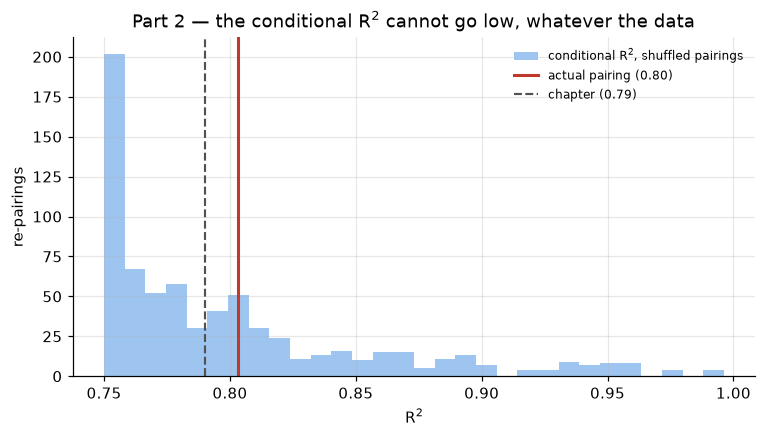

In [11]:
# Permutation check: refit on every possible re-pairing of observed to predicted.
from itertools import permutations
import statsmodels.formula.api as smf

def refit(observed):
    frame = pd.DataFrame({"observed": observed, "predicted": d2.predicted.to_numpy(),
                          "year_group": d2.year.astype(str).to_numpy()})
    f = smf.mixedlm("observed ~ predicted", data=frame, groups=frame.year_group).fit(method="lbfgs")
    yy = np.asarray(observed, float); sst = ((yy - yy.mean()) ** 2).sum()
    fx = f.params["Intercept"] + f.params["predicted"] * frame.predicted
    return (1 - ((yy - f.fittedvalues) ** 2).sum() / sst,
            1 - ((yy - fx) ** 2).sum() / sst)

shuffled_cond, shuffled_marg = [], []
for perm in permutations(range(len(y))):
    try:
        c, m_ = refit(y[list(perm)]); shuffled_cond.append(c); shuffled_marg.append(m_)
    except Exception:
        pass
shuffled_cond, shuffled_marg = np.array(shuffled_cond), np.array(shuffled_marg)

print(f"all {len(shuffled_cond)} re-pairings of the same six numbers:")
print(f"  conditional R2: mean {shuffled_cond.mean():.3f}, range "
      f"{shuffled_cond.min():.3f}-{shuffled_cond.max():.3f}")
print(f"  re-pairings reaching >= 0.79 : {(shuffled_cond >= 0.79).mean()*100:.0f}%")
print(f"  re-pairings beating the true marginal R2: {(shuffled_marg > marg).mean()*100:.0f}%"
      "   <- permutation p-value")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(shuffled_cond, bins=30, color="#9ec5f0", label="conditional R$^2$, shuffled pairings")
ax.axvline(cond, color="#c0392b", lw=2, label=f"actual pairing ({cond:.2f})")
ax.axvline(0.79, color="#52514e", ls="--", lw=1.4, label="chapter (0.79)")
ax.set(xlabel="R$^2$", ylabel="re-pairings",
       title="Part 2 — the conditional R$^2$ cannot go low, whatever the data")
ax.legend(frameon=False, fontsize=8); plt.show()

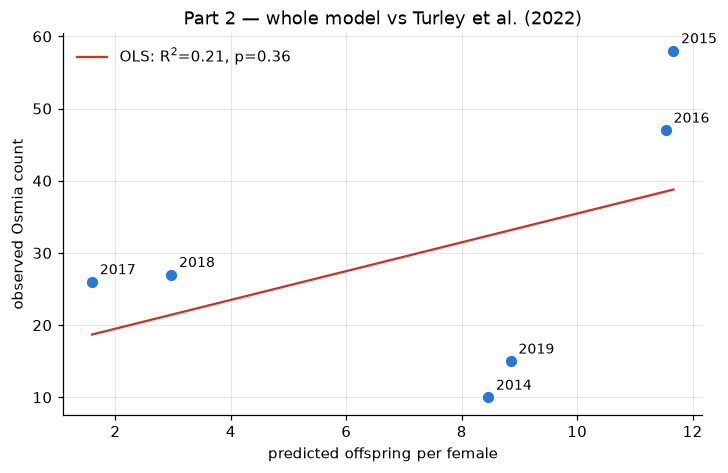

In [12]:
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.scatter(d2.predicted, d2.observed, s=70, color="#2a78d6", edgecolor="white", zorder=3)
for _, r_ in d2.iterrows():
    ax.annotate(int(r_.year), (r_.predicted, r_.observed), fontsize=9,
                xytext=(5, 5), textcoords="offset points")
xs = np.linspace(d2.predicted.min(), d2.predicted.max(), 50)
ax.plot(xs, ols.intercept + ols.slope * xs, color="#c0392b", lw=1.5,
        label=f"OLS: R$^2$={ols.rvalue**2:.2f}, p={ols.pvalue:.2f}")
ax.set(xlabel="predicted offspring per female", ylabel="observed Osmia count",
       title="Part 2 — whole model vs Turley et al. (2022)")
ax.legend(frameon=False); plt.show()

**Read.** The chapter's R² = 0.79 reproduces (0.803), but it is carried by the
random intercept: fixed effects alone explain 21%, at p = 0.36. The permutation
check makes this concrete — deliberately mispairing the same six numbers gives a
conditional R² averaging ~0.80, and a third of wrong pairings score *higher* than
the correct one.

Six annual points at one site is not enough to evaluate a model with four
sub-models. Part 3 is where the model's behaviour actually becomes visible.

---
# Part 3 — 16 years across the region

Run every grid cell for weather years **2008–2023**, reporting reproductive
success for springs **2009–2024**. The window is set by the forage index, which
is the shortest input series.

`REGION_CELLS` drives the extent — swap in a wider cell list once weather and
forage exist for it.

In [13]:
# The Northeast inputs are used when present; Pennsylvania is the fallback so the
# notebook runs on a fresh clone that has not fetched them.
from applebee.config import NE_FORAGE_CSV, NE_PPT_KEY, NE_TMEAN_KEY, NE_WEATHER_DIR
from applebee.weather import load_matrices

NORTHEAST_AVAILABLE = NE_FORAGE_CSV.exists() and (NE_WEATHER_DIR / f"{NE_TMEAN_KEY}.values.npy").exists()

if NORTHEAST_AVAILABLE:
    REGION_NAME   = "Northeast"
    tmean_r       = load_matrices(NE_WEATHER_DIR, NE_TMEAN_KEY)
    ppt_r         = load_matrices(NE_WEATHER_DIR, NE_PPT_KEY)
    forage_r      = ForageGrid.load(NE_FORAGE_CSV)
    WEATHER_YEARS = range(2013, 2019)          # -> offspring springs 2014-2019
    weather_cells = {(int(c), int(r)) for c, r in zip(tmean_r.cells["col"], tmean_r.cells["row"])}
    REGION_CELLS  = [c for c in forage_r.cells if c in weather_cells]
    SIM_CACHE     = ROOT / "outputs" / "northeast_simulation.parquet"
else:
    REGION_NAME   = "Pennsylvania"
    tmean_r, ppt_r, forage_r = tmean, ppt, forage
    WEATHER_YEARS = range(2008, 2024)
    REGION_CELLS  = forage.cells
    SIM_CACHE     = ROOT / "outputs" / "pa_simulation_default.parquet"

print(f"{REGION_NAME}: {len(REGION_CELLS):,} cells x {len(list(WEATHER_YEARS))} years "
      f"= {len(REGION_CELLS)*len(list(WEATHER_YEARS)):,} cell-years")
print(f"weather years {min(WEATHER_YEARS)}-{max(WEATHER_YEARS)} "
      f"-> offspring springs {min(WEATHER_YEARS)+1}-{max(WEATHER_YEARS)+1}")

Northeast: 44,759 cells x 6 years = 268,554 cell-years
weather years 2013-2018 -> offspring springs 2014-2019


In [14]:
RERUN = False                                   # True to recompute (~40 s)

if RERUN or not SIM_CACHE.exists():
    start = time.time()
    region_model = AppleBee(tmean_r, ppt_r, forage_r, ModelParams())
    sim, failures = region_model.run(REGION_CELLS, WEATHER_YEARS, progress=True)
    print(f"\n{len(sim):,} cell-years in {time.time()-start:.0f}s, {len(failures)} failures")
    if len(failures):
        print(failures["error"].value_counts().to_string())
else:
    sim = pd.read_parquet(SIM_CACHE)
    print(f"loaded cached run: {len(sim):,} cell-years")

sim.head()

loaded cached run: 268,536 cell-years


,col,row,weather_year,offspring_year,emergence_doy,emergence_date,eggs,forage_quality,eggs_per_day,egg_larva_mortality,winter_mortality,offspring,mean_cold_days,mean_hot_days,prewinter_warm_days,no_egg_days_temperature,no_egg_days_precipitation,lon,lat
0,1008,141,2013,2014,148,2013-05-28,9,0.332830,1,0.0,0.0800,8.2800,0.0,0.0,32,8,3,-83.0,44.041667
1,1008,142,2013,2014,147,2013-05-27,8,0.212065,1,0.0,0.0775,7.3800,0.0,0.0,31,6,6,-83.0,44.000000
2,1008,143,2013,2014,143,2013-05-23,6,0.278417,1,0.0,0.0775,5.5350,0.0,0.0,31,9,5,-83.0,43.958333
3,1008,144,2013,2014,142,2013-05-22,6,0.168716,1,0.0,0.0800,5.5200,0.0,0.0,32,10,5,-83.0,43.916667
4,1008,145,2013,2014,142,2013-05-22,7,0.263182,1,0.0,0.0825,6.4225,0.0,0.0,33,10,4,-83.0,43.875000


## 3.1 How much does reproductive success vary?

In [15]:
per_cell_sd   = sim.groupby(["col","row"]).offspring.std()
per_cell_mean = sim.groupby(["col","row"]).offspring.mean()
by_year       = sim.groupby("offspring_year").offspring.agg(["mean","std","min","max"])

print(f"offspring per female across all {len(sim):,} cell-years:")
print(f"  max {sim.offspring.max():.1f}   mean {sim.offspring.mean():.2f}   min {sim.offspring.min():.2f}")
print(f"\nvariability THROUGH TIME  (SD of a cell's {sim.offspring_year.nunique()} annual values):")
print(f"  max {per_cell_sd.max():.2f}   mean {per_cell_sd.mean():.2f}   min {per_cell_sd.min():.2f}")
print(f"variability ACROSS SPACE  (SD of the {len(per_cell_mean):,} cell means):")
print(f"  {per_cell_mean.std():.2f}")
print(f"\n-> year-to-year variation within a cell is roughly "
      f"{per_cell_sd.mean()/per_cell_mean.std():.1f}x the spatial variation between cells.")
display(by_year.round(2))

offspring per female across all 268,536 cell-years:
  max 34.8   mean 14.73   min 0.00

variability THROUGH TIME  (SD of a cell's 6 annual values):
  max 12.50   mean 4.99   min 0.21
variability ACROSS SPACE  (SD of the 44,756 cell means):
  4.59

-> year-to-year variation within a cell is roughly 1.1x the spatial variation between cells.


,mean,std,min,max
offspring_year,,,,
2014,13.07,5.60,0.89,31.45
2015,18.03,6.00,2.16,34.77
2016,14.55,5.50,0.00,33.53
2017,12.97,7.71,0.00,33.92
2018,12.38,6.11,0.00,31.88
2019,17.41,6.77,0.00,34.48


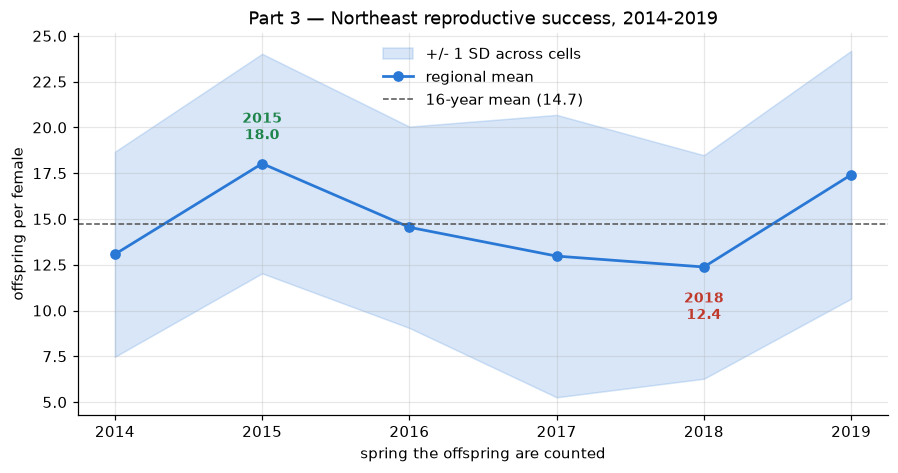

worst year 2018: 12.38    best year 2015: 18.03    ratio 1.5x


In [16]:
fig, ax = plt.subplots(figsize=(9.5, 4.5))
ax.fill_between(by_year.index, by_year["mean"]-by_year["std"], by_year["mean"]+by_year["std"],
                color="#2a78d6", alpha=0.18, label="+/- 1 SD across cells")
ax.plot(by_year.index, by_year["mean"], marker="o", color="#2a78d6", lw=1.8, label="regional mean")
ax.axhline(sim.offspring.mean(), ls="--", color="#52514e", lw=1,
           label=f"16-year mean ({sim.offspring.mean():.1f})")
worst, best = by_year["mean"].idxmin(), by_year["mean"].idxmax()
for yr, colour in [(worst, "#c0392b"), (best, "#1e8449")]:
    ax.annotate(f"{yr}\n{by_year.loc[yr,'mean']:.1f}", (yr, by_year.loc[yr,"mean"]),
                xytext=(0, -34 if yr == worst else 16), textcoords="offset points",
                ha="center", color=colour, fontweight="bold", fontsize=9)
ax.set(xlabel="spring the offspring are counted", ylabel="offspring per female",
       title=f"Part 3 — {REGION_NAME} reproductive success, "
             f"{sim.offspring_year.min()}-{sim.offspring_year.max()}")
ax.legend(frameon=False); plt.show()

print(f"worst year {worst}: {by_year.loc[worst,'mean']:.2f}    "
      f"best year {best}: {by_year.loc[best,'mean']:.2f}    "
      f"ratio {by_year.loc[best,'mean']/by_year.loc[worst,'mean']:.1f}x")

## 3.2 Where is it high, and where is it volatile?

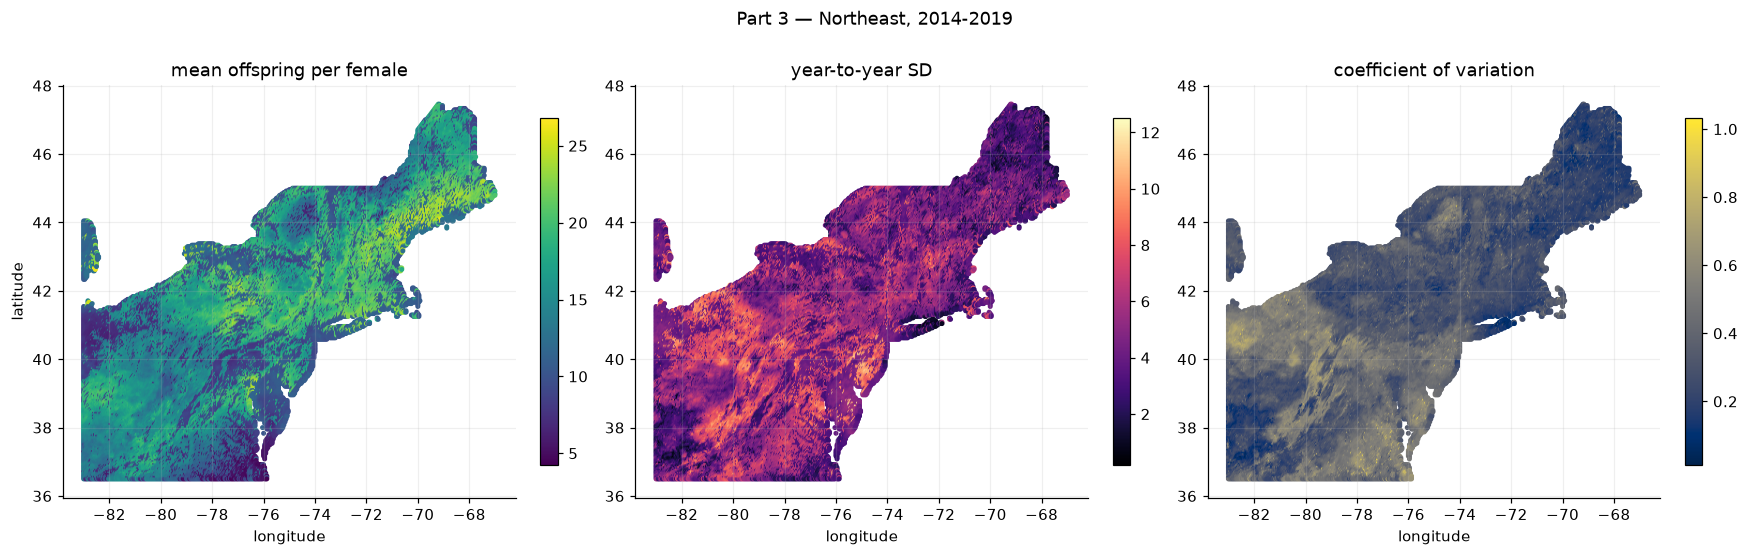

In [17]:
coords = tmean_r.cells[["col","row","lon","lat"]]
if {"lon","lat"} <= set(sim.columns):
    coords = sim[["col","row","lon","lat"]].drop_duplicates()
maps = (per_cell_mean.rename("mean_offspring").to_frame()
        .join(per_cell_sd.rename("sd_offspring"))
        .reset_index().merge(coords, on=["col","row"], how="left"))
maps["cv"] = maps.sd_offspring / maps.mean_offspring

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
aspect = 1 / np.cos(np.radians(maps.lat.mean()))
for ax, (field, cmap, title) in zip(axes, [("mean_offspring","viridis","mean offspring per female"),
                                           ("sd_offspring","magma","year-to-year SD"),
                                           ("cv","cividis","coefficient of variation")]):
    sc = ax.scatter(maps.lon, maps.lat, c=maps[field], s=5, cmap=cmap)
    fig.colorbar(sc, ax=ax, fraction=0.035)
    ax.set(title=title, xlabel="longitude")
    ax.set_aspect(aspect); ax.grid(alpha=0.2)
axes[0].set_ylabel("latitude")
fig.suptitle(f"Part 3 — {REGION_NAME}, {sim.offspring_year.min()}-{sim.offspring_year.max()}", y=1.04)
plt.tight_layout(); plt.show()

## 3.3 What drives the year-to-year swings?

In [18]:
drivers = sim.groupby("offspring_year").agg(
    offspring=("offspring","mean"), eggs=("eggs","mean"),
    emergence_doy=("emergence_doy","mean"),
    egg_larva_mortality=("egg_larva_mortality","mean"),
    winter_mortality=("winter_mortality","mean"),
    no_egg_T=("no_egg_days_temperature","mean"),
    no_egg_P=("no_egg_days_precipitation","mean")).round(2)
display(drivers)

print("correlation of each driver with the regional annual mean offspring:")
for c in ["eggs","emergence_doy","egg_larva_mortality","winter_mortality","no_egg_T","no_egg_P"]:
    r = np.corrcoef(drivers[c], drivers.offspring)[0,1]
    print(f"  {c:22s} r = {r:+.3f}")

,offspring,eggs,emergence_doy,egg_larva_mortality,winter_mortality,no_egg_T,no_egg_P
offspring_year,,,,,,,
2014,13.07,15.54,133.38,0.08,0.08,7.41,5.04
2015,18.03,20.16,136.24,0.02,0.09,4.53,4.14
2016,14.55,17.45,131.93,0.07,0.10,6.64,4.04
2017,12.97,15.58,129.38,0.12,0.10,8.46,4.06
2018,12.38,15.15,123.18,0.12,0.09,8.36,5.11
2019,17.41,19.74,132.35,0.03,0.10,4.57,4.45


correlation of each driver with the regional annual mean offspring:
  eggs                   r = +0.996
  emergence_doy          r = +0.702
  egg_larva_mortality    r = -0.953
  winter_mortality       r = +0.241
  no_egg_T               r = -0.981
  no_egg_P               r = -0.470


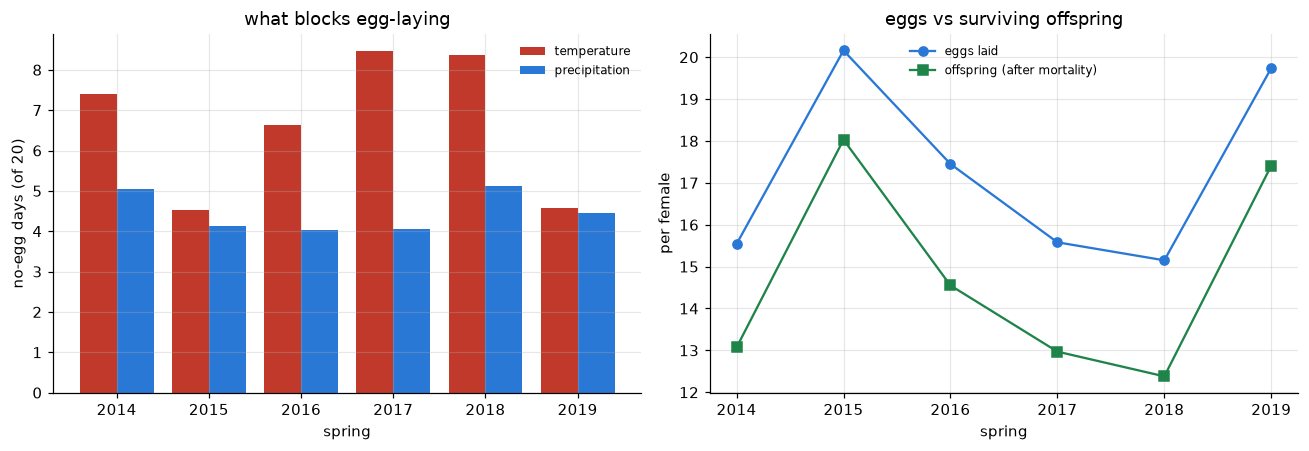

temperature-limited days 6.66 +- 3.63
precipitation-limited    4.47 +- 2.06
Welch t = 271.4, p = 0  -> temperature is the dominant constraint


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].bar(drivers.index - 0.2, drivers.no_egg_T, width=0.4, label="temperature", color="#c0392b")
axes[0].bar(drivers.index + 0.2, drivers.no_egg_P, width=0.4, label="precipitation", color="#2a78d6")
axes[0].set(xlabel="spring", ylabel="no-egg days (of 20)", title="what blocks egg-laying")
axes[0].legend(frameon=False, fontsize=8)

ax2 = axes[1]
ax2.plot(drivers.index, drivers.eggs, marker="o", color="#2a78d6", label="eggs laid")
ax2.plot(drivers.index, drivers.offspring, marker="s", color="#1e8449", label="offspring (after mortality)")
ax2.set(xlabel="spring", ylabel="per female", title="eggs vs surviving offspring")
ax2.legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

t_stat, p_val = stats.ttest_ind(sim.no_egg_days_temperature, sim.no_egg_days_precipitation,
                                equal_var=False)
print(f"temperature-limited days {sim.no_egg_days_temperature.mean():.2f} +- "
      f"{sim.no_egg_days_temperature.std():.2f}")
print(f"precipitation-limited    {sim.no_egg_days_precipitation.mean():.2f} +- "
      f"{sim.no_egg_days_precipitation.std():.2f}")
print(f"Welch t = {t_stat:.1f}, p = {p_val:.3g}  -> temperature is the dominant constraint")

## 3.4 Which sub-model matters most?

random forest R2 on held-out cell-years: 1.0000


,sub-model,importance %
1,Egg production,95.426
2,Egg and larva mortality,4.354
3,Winter mortality,0.217
0,Julian emergence date,0.003


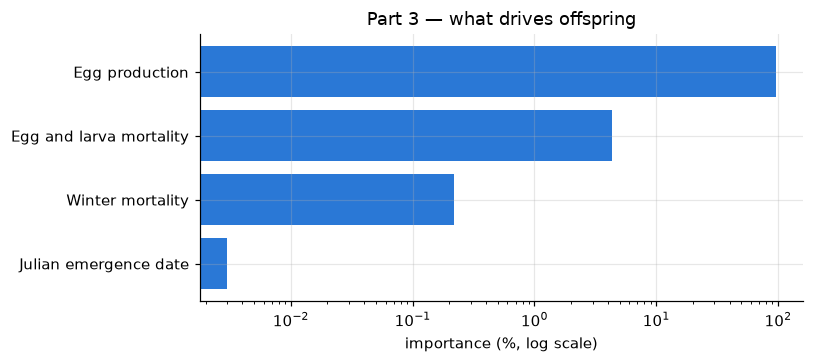

In [20]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

FEATURES = {"emergence_doy":"Julian emergence date", "eggs":"Egg production",
            "egg_larva_mortality":"Egg and larva mortality", "winter_mortality":"Winter mortality"}
X = sim[list(FEATURES)].to_numpy(float); yv = sim.offspring.to_numpy(float)
Xtr, Xte, ytr, yte = train_test_split(X, yv, test_size=0.2, random_state=0)
scaler = StandardScaler().fit(Xtr)
forest = RandomForestRegressor(n_estimators=100, random_state=0, n_jobs=-1).fit(scaler.transform(Xtr), ytr)

imp = (pd.DataFrame({"sub-model": list(FEATURES.values()),
                     "importance %": (forest.feature_importances_*100).round(3)})
       .sort_values("importance %", ascending=False))
print(f"random forest R2 on held-out cell-years: {forest.score(scaler.transform(Xte), yte):.4f}")
display(imp)

fig, ax = plt.subplots(figsize=(7.5, 3.4))
ax.barh(imp["sub-model"], imp["importance %"], color="#2a78d6")
ax.set(xscale="log", xlabel="importance (%, log scale)", title="Part 3 — what drives offspring")
ax.invert_yaxis(); plt.tight_layout(); plt.show()

## 3.5 The site from Part 2, in regional context

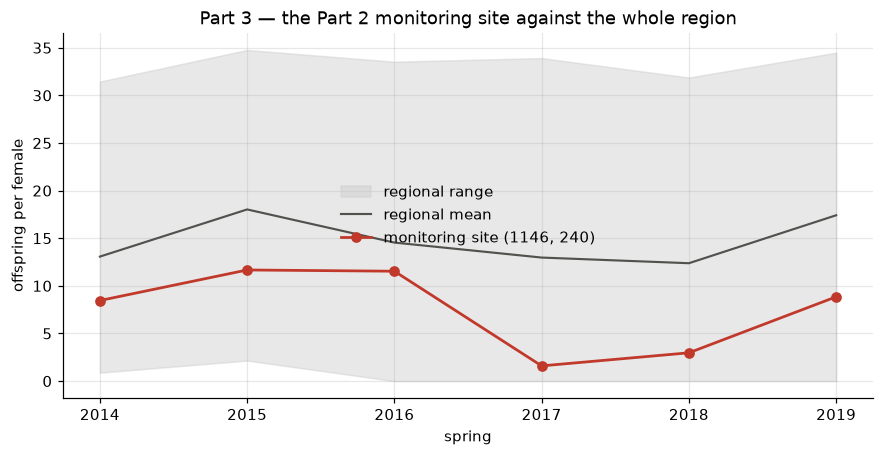

the monitoring site's 6-year mean is 7.51, the 6th percentile of cells
-> one site cannot represent regional variability, which is the case for Part 3.


In [21]:
site = sim[(sim.col == col) & (sim.row == row)].sort_values("offspring_year")
if site.empty:
    raise SystemExit("monitoring site is outside the simulated region")
fig, ax = plt.subplots(figsize=(9.5, 4.3))
ax.fill_between(by_year.index, by_year["min"], by_year["max"], color="#cccccc", alpha=0.45,
                label="regional range")
ax.plot(by_year.index, by_year["mean"], color="#52514e", lw=1.4, label="regional mean")
ax.plot(site.offspring_year, site.offspring, marker="o", color="#c0392b", lw=1.8,
        label=f"monitoring site ({col}, {row})")
ax.set(xlabel="spring", ylabel="offspring per female",
       title="Part 3 — the Part 2 monitoring site against the whole region")
ax.legend(frameon=False); plt.show()

pct = (per_cell_mean < per_cell_mean.loc[(col, row)]).mean() * 100
print(f"the monitoring site's {sim.offspring_year.nunique()}-year mean is {per_cell_mean.loc[(col,row)]:.2f}, "
      f"the {pct:.0f}th percentile of cells")
print("-> one site cannot represent regional variability, which is the case for Part 3.")

---
## Summary

| Step | Data | What it tests | Result |
|---|---|---|---|
| 1 | Centrella et al. (2020) — 51 site-windows, NY 2015 | egg production alone, emergence observed | R² 0.41 default, 0.48 calibrated; calibration gain +0.07 against the chapter's +0.08 |
| 2 | Turley et al. (2022) — 6 annual counts, one PA site | all four sub-models, emergence predicted | conditional R² 0.80 reproduces the chapter's 0.79, but marginal R² is 0.21 at p = 0.36 |
| 3 | PRISM + Lonsdorf — 44,756 Northeast cells × 6 years | model behaviour in space and time | temperature-limited days dominate; egg production correlates +0.996 with annual mean offspring |

**The evaluation is the weak link, not the simulation.** Step 1 is limited by a
response variable that is not in the published dataset; step 2 by six
observations at a single site. Step 3 runs 119,232 cell-years and its qualitative
behaviour is stable — but it inherits whatever bias the two evaluation steps
could not detect.

### Extending step 3 to the wider Northeast

Two datasets are missing, both obtainable:

1. **Daily PRISM `tmean` and `ppt`** for a Northeast bounding box, 2008–2024 —
   roughly 10× the Pennsylvania volume. `scripts/build_cache.py` already converts
   wide PRISM exports into the cached matrices this notebook reads.
2. **The Lonsdorf spring forage index** per 4 km cell per year for each state,
   built from the USDA Cropland Data Layer with Koh et al. (2016) weights. The
   R notebooks that did this for Pennsylvania are in
   `archives/R_scripts/Process_CDL_To_SFRQ_PA.Rmd`.

With those in place, only `REGION_CELLS` in §3 changes.